# Intelligent Phishing Website Detection Using Machine Learning

# Part 2 – Data Preprocessing & Feature Engineering

This notebook covers:

1. Data Cleaning
2. Feature Engineering
3. Feature Selection
4. Data Preprocessing
5. Train/Test Split
6. Save Preprocessing Objects


In [1]:
# ==========================
# Import Libraries
# ==========================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import joblib


In [2]:
# ==========================
# Load Dataset
# ==========================
DATASET_PATH='PhiUSIIL_Phishing_URL_Dataset.csv'
df = pd.read_csv(DATASET_PATH)

print(df.shape)
df.head()


(235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [3]:
# ==========================
# Basic Cleaning
# ==========================

print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

print("Missing Values:")
print(df.isnull().sum().sum())

df = df.dropna()

print("Final Shape:", df.shape)


Duplicates: 0


Missing Values:
0
Final Shape: (235795, 56)


In [4]:
# ==========================
# Feature Engineering
# ==========================

# Create additional features if source columns exist

if 'URLLength' in df.columns and 'DomainLength' in df.columns:
    df['URL_Domain_Ratio'] = df['URLLength'] / (df['DomainLength'] + 1)

if 'NoOfDigitsInURL' in df.columns and 'URLLength' in df.columns:
    df['Digit_Ratio'] = df['NoOfDigitsInURL'] / (df['URLLength'] + 1)

if 'NoOfSpecialCharsInURL' in df.columns and 'URLLength' in df.columns:
    df['SpecialChar_Ratio'] = df['NoOfSpecialCharsInURL'] / (df['URLLength'] + 1)

print("Feature Engineering Complete")
print(df.shape)


Feature Engineering Complete
(235795, 57)


In [5]:
# ==========================
# Prepare Features
# ==========================

TARGET = 'label'

X = df.drop(columns=[TARGET])

non_numeric_cols = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
cols_to_drop = [col for col in non_numeric_cols if col in X.columns]
X = X.drop(columns=cols_to_drop)

y = df[TARGET]

print(X.shape)


(235795, 51)


In [6]:
# ==========================
# Feature Selection - Mutual Information
# ==========================

selector = SelectKBest(score_func=mutual_info_classif,
                       k=min(30, X.shape[1]))

X_selected = selector.fit_transform(X, y)

selected_columns = X.columns[selector.get_support()]

scores = pd.DataFrame({
    'Feature': X.columns,
    'Selected': selector.get_support()
})

display(scores.sort_values('Selected', ascending=False))


,Feature,Selected
0,URLLength,True
20,SpacialCharRatioInURL,True
22,LineOfCode,True
23,LargestLineLength,True
24,HasTitle,True
26,URLTitleMatchScore,True
29,IsResponsive,True
32,HasDescription,True
34,NoOfiFrame,True
36,HasSocialNet,True


,Feature,Importance
3,URLSimilarityIndex,0.175633
49,NoOfExternalRef,0.134017
22,LineOfCode,0.105288
44,NoOfImage,0.098571
47,NoOfSelfRef,0.096193
46,NoOfJS,0.090382
36,HasSocialNet,0.048659
43,HasCopyrightInfo,0.042357
45,NoOfCSS,0.039970
19,NoOfOtherSpecialCharsInURL,0.027912


<Axes: title={'center': 'Top 20 Feature Importance'}, ylabel='Feature'>

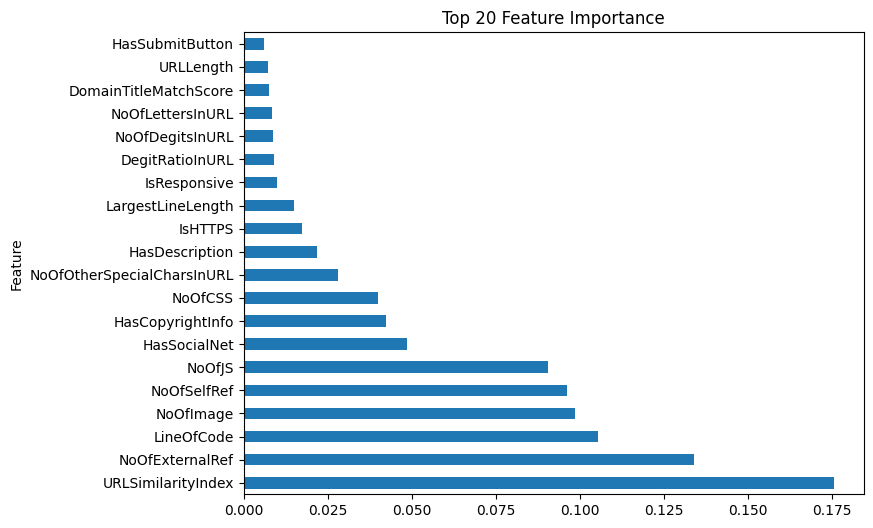

In [7]:
# ==========================
# Random Forest Feature Importance
# ==========================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

display(importance.head(20))

importance.head(20).plot.barh(
    x='Feature',
    y='Importance',
    figsize=(8,6),
    legend=False,
    title='Top 20 Feature Importance'
)


In [8]:
# ==========================
# Scaling
# ==========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X[selected_columns])

print(X_scaled.shape)


(235795, 30)


In [9]:
# ==========================
# Train Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (188636, 30)
Test : (47159, 30)


In [10]:
# ==========================
# Save Preprocessing Objects
# ==========================

joblib.dump(scaler, 'preprocessor.pkl')
joblib.dump(list(selected_columns), 'feature_columns.pkl')

print("Saved:")
print("- preprocessor.pkl")
print("- feature_columns.pkl")


Saved:
- preprocessor.pkl
- feature_columns.pkl


# Summary

✔ Data cleaned

✔ New engineered features created (when applicable)

✔ Best features selected using Mutual Information

✔ Feature importance generated using Random Forest

✔ Data standardized

✔ Train/Test split completed

✔ Preprocessing objects saved

The next notebook will train and compare multiple machine learning models:
- Logistic Regression
- Decision Tree
- Random Forest
- SVM
- XGBoost
